# Métodos de Interpolação

## Lagrange

In [9]:
import numpy as np
import matplotlib.pyplot as plt

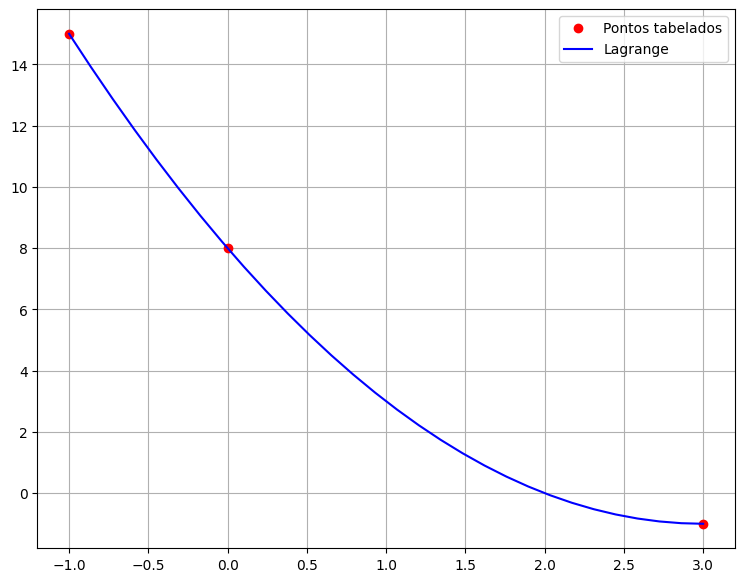

In [10]:
xi = np.array([-1., 0, 3])
yi = np.array([15, 8, -1])

n = xi.shape[0]

N = 30

# cria uma malha espalhando os pontos
x = np.linspace(xi[0], xi[n - 1], N)

L = np.ones((n, N))

for i in range (0, n):
    for j in range (0, n):
        if i != j:
            L[i, :] *= (x - xi[j]) / (xi[i] - xi[j])

y = yi @ L 


# ponto = ?
# n = len(x)
# L = np.ones(n)
# 
# for i in range (0, n):
#     for j in range (0, n):
#         if i != j:
#             L[i] = L[i] * (ponto - x[j] ) / (x[i] - x[j])
# 
# ponto_lagrange = y @ L
# print (ponto_lagrange) 



plt.figure(figsize=(9, 7))
plt.plot(xi, yi, 'ro', label='Pontos tabelados')
plt.plot(x, y, 'b-', label='Lagrange')
plt.grid()
plt.legend()
plt.show()

# Newton-Gregory

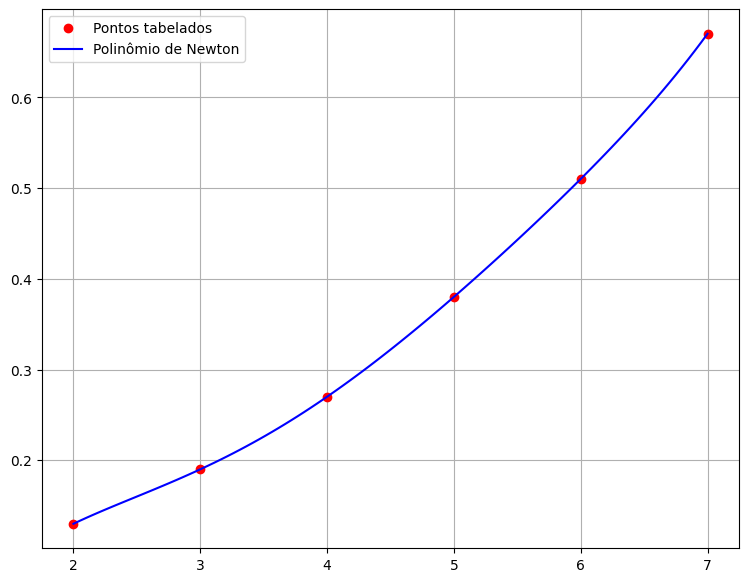

In [11]:
xi = np.array([2., 3, 4, 5, 6, 7])
yi = np.array([0.13, 0.19, 0.27, 0.38, 0.51, 0.67])

n = xi.shape[0]

N = 100

x = np.linspace(xi[0], xi[n - 1], N)

D = np.zeros((n, n))

D[:, 0] = yi.T

# Calcula todas as diferenças Divididas
for j in range(1, n):
    for i in range (j, n):
        D[i,j] = (D[i, j-1] - D[i-1, j-1]) / (xi[i] - xi[i-j])

c = np.diag(D)

y = np.ones(N) * c[0] 

xv = np.ones(N)

for j in range (1, n):
    xv *= (x - xi[j-1])
    y = y + c[j] * xv

plt.figure(figsize=(9, 7))
plt.plot(xi, yi, 'ro', label='Pontos tabelados')
plt.plot(x, y, 'b-', label='Polinômio de Newton')
plt.grid()
plt.legend()
plt.show()




# x_v = ?
# y_v = c[0]
# 
# xv_v = 1
# 
# for j in range (1, n):
#     xv_v = xv_v * (x_v - xi[j-1])
#     y_v = y_v + c[j] * xv_v
# print(f"{x_v} : {y_v}") 



## Spline cúbico natural

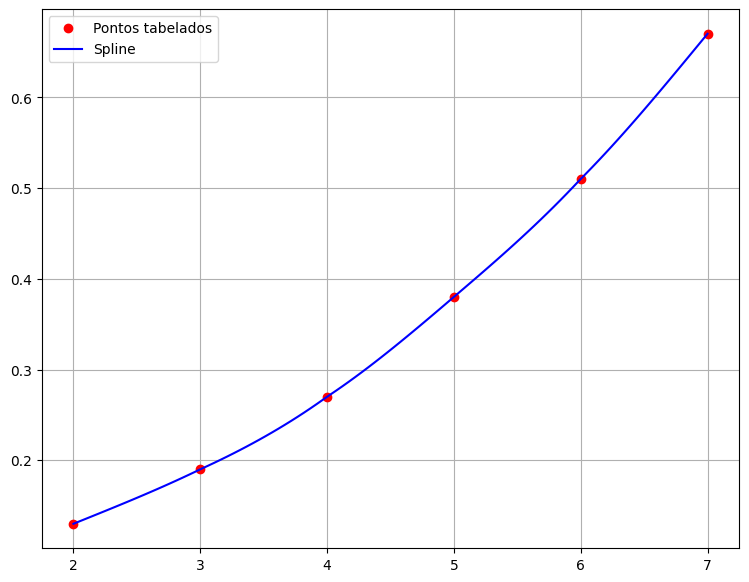

In [12]:
xi = np.array([2., 3, 4, 5, 6, 7])
yi = np.array([0.13, 0.19, 0.27, 0.38, 0.51, 0.67])

n = xi.shape[0]

N = 100

x = np.linspace(xi[0], xi[n - 1], N)

m = n - 1

h = np.zeros(n-1)

for i in range (0, n-1):
    h[i] = xi[i+1] - xi[i]


a = yi
A = np.zeros((n, n))
r = np.zeros(n)

A[0,0] = 1
A[n-1,n-1] = 1

for j in range(1, n-1):
    A[j, j-1] = h[j-1]
    A[j, j] = 2 * h[j-1] + h[j]
    A[j, j+1] = h[j]
    r[j] = 3 * ((a[j+1] - a[j]) / h[j] - (a[j] - a[j-1]) / h[j-1])

c = np.linalg.solve(A, r)

d = np.zeros(m)

b = np.zeros(m)

for j in range (0, m):
    d[j] = (c[j+1] - c[j]) / (3 * h[j])
    b[j] = (a[j+1] - a[j]) / h[j] - h[j] / 3 * (2 * c[j] + c[j+1])


y = np.zeros(N)

for k in range (0, N):
    id = m
    for j in range (0, m):
        if x[k] <= xi[j+1]:
            id = j
            break
    t = x[k] - xi[id]
    y[k] = a[id] + b[id] * t + c[id] * t**2 + d[id] * t ** 3

plt.figure(figsize=(9, 7))
plt.plot(xi, yi, 'ro', label='Pontos tabelados')
plt.plot(x, y, 'b-', label='Spline')
plt.grid()
plt.legend()
plt.show()


# pode não ser exato!
# ponto = ?
# 
# n = len(x)
# 
# m = n - 1 
# 
# h = np.zeros(m)
# 
# for i in range(m):
#     h[i] = x[i + 1] - x[i]
# 
# a = y
# 
# A = np.zeros((n, n))
# 
# r = np.zeros(n)
# 
# A[0, 0] = 1
# A[n - 1, n - 1] = 1
# 
# for j in range(1, n - 1):
#     A[j, j - 1] = h[j - 1]
#     A[j, j] = 2 * (h[j - 1] + h[j])
#     A[j, j + 1] = h[j]
#     r[j] = 3 * (((a[j+1] - a[j]) / h[j]) - ((a[j] - a[j-1]) / h[j-1]))
# 
# c = np.linalg.solve(A, r)
# 
# idx = 0
# 
# for j in range(0, m):
#     if ponto <= x[j + 1]:
#         idx = j
#         break
# 
# d = (c[idx + 1] - c[idx]) / (3 * h[idx])
# 
# b = ((a[idx + 1] - a[idx]) / h[idx]) - ((h[idx] / 3) * (2 * c[idx] + c[idx + 1]))
# 
# t = ponto - x[idx]
# 
# ponto_spline = a[idx] + b * t + c[idx] * (t**2) + d * (t**3)
# 
# print(f"spline cúbico : ponto {ponto} : {ponto_spline}")
# 

